In [17]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

- load the data

In [2]:
dim=256
kappa = 0.1
output_dir = Path(f'../outputs/cfm/kappagmm_{dim}_{kappa}')
mus = torch.load(output_dir / 'mus.pt')
m1 = (mus[0] + mus[1]) / 2
m2 = (mus[0] - mus[1]) / 2
sampling_data = torch.load(output_dir / 'sampling_data.pt')

nsamples = int(1e4)
p1 = sampling_data['data'][:,:nsamples] @ m1.cpu().numpy() / dim
p2 = sampling_data['data'][:,:nsamples] @ m2.cpu().numpy() / dim

/tmp/ipykernel_12471/1440586187.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mus = torch.load(output_dir / 'mus.pt')
/tmp/ipykernel_12471/1440586187.py:7: FutureWarni

- ref samples

In [14]:
ref_samples = (mus.unsqueeze(0) + torch.randn((nsamples // 4, *mus.shape), device=mus.device)).reshape(-1,dim)
r1 = (ref_samples @ m1 / dim).cpu().numpy()
r2 = (ref_samples @ m2 / dim).cpu().numpy()

- plot

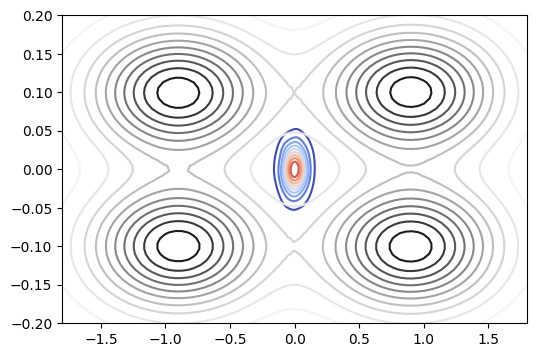

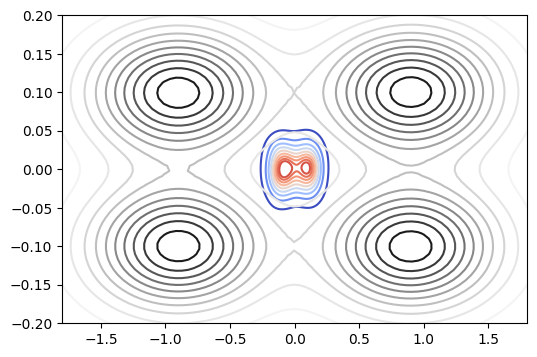

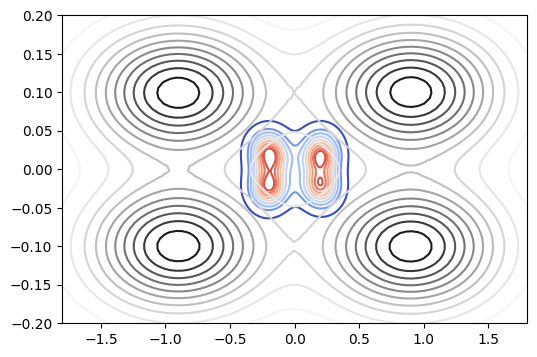

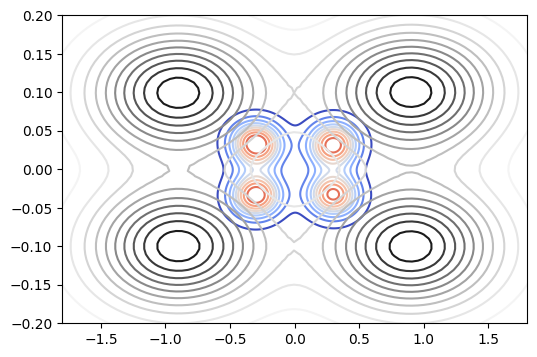

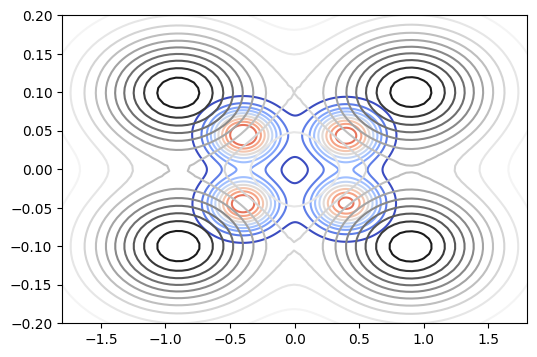

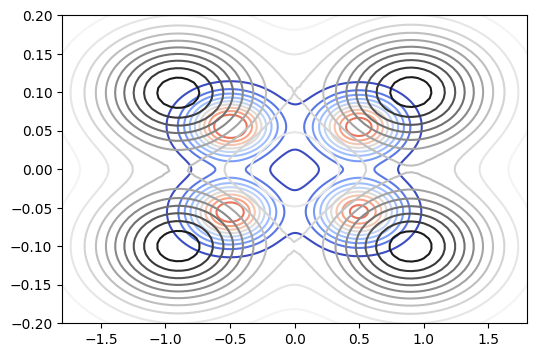

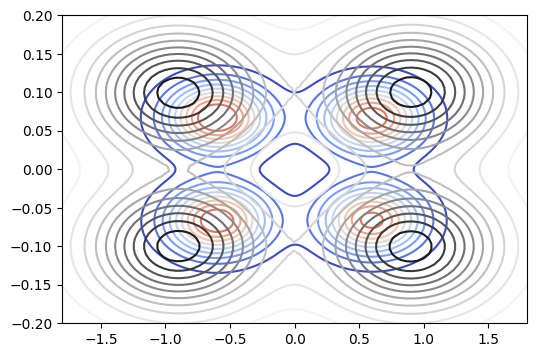

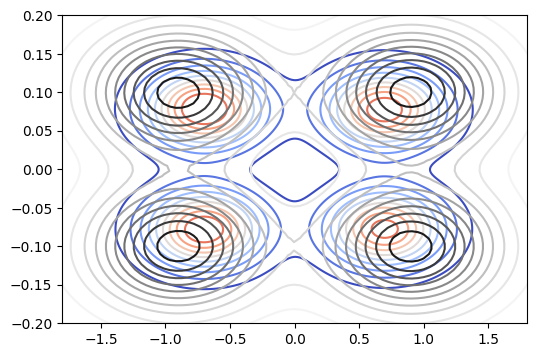

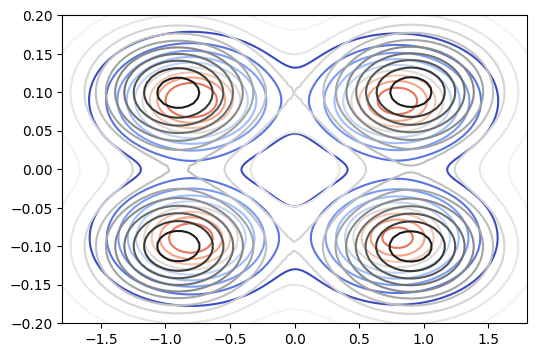

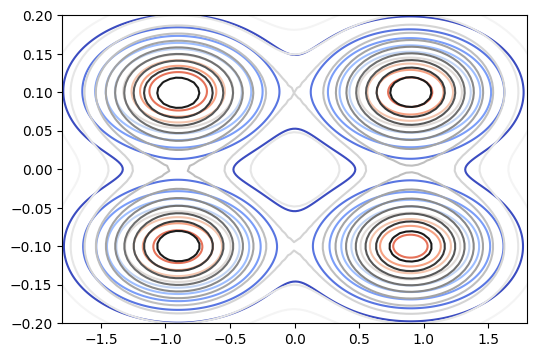

In [24]:
# Pre-compute reference KDE once
kde_ref = gaussian_kde(np.vstack([r1, r2]), bw_method=0.5)
# Pre-evaluate on a fixed grid once
x_grid = np.linspace(2 * r1.min(), 2 * r1.max(), 100)
y_grid = np.linspace(2 * r2.min(), 2 * r2.max(), 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = kde_ref(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

for i in range(p1.shape[0]):

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    sns.kdeplot(
                x=p1[i], 
                y=p2[i],
                ax=ax,
                cmap='coolwarm',
                fill=False,      # no fill, just contour lines
                levels=10,       # number of iso-density levels
                bw_adjust=2.0,
            )
    
    # use precomputed for reference
    ax.contour(X, Y, Z, levels=10, cmap='Greys')
    # sns.kdeplot(
    #             x=r1, 
    #             y=r2,
    #             ax=ax,
    #             cmap='Greys',
    #             fill=False,      # no fill, just contour lines
    #             levels=10,       # number of iso-density levels
    #             bw_adjust=2.0,
    #         )
    ax.set_xlim(-2 * (1-kappa), 2 * (1-kappa))
    ax.set_ylim(-2 * kappa, 2 * kappa)
    plt.show()
# ax.set_title(f"Basis {i}")

Okay so this was clearly sufficient training to learn this distribution.
We see no issues at inference.